## RAGAS Evaluation — End-to-End Pipeline

Đánh giá chất lượng sinh câu trả lời của pipeline trên nhánh HEALTH_ADVICE.

**Dataset:** `data/en/eval_200.jsonl` — 200 Q&A pairs (LLM-generated ground truth)  
**Eval subset:** 30 câu HEALTH_ADVICE (filter bỏ abstract-style và NUTRITION_LOOKUP)  
**Judge LLM:** Gemini API (`gemini-2.0-flash` by default)  
**Embeddings:** sentence-transformers/all-MiniLM-L6-v2 (cho AnswerRelevancy)

**Metrics:**
| Metric | Mô tả |
|---|---|
| Faithfulness | Answer có bịa nội dung ngoài context không? |
| Answer Relevancy | Answer có trả lời đúng câu hỏi không? |
| Context Precision | Chunks retrieved có liên quan không? |
| Context Recall | Context có bao phủ ground truth không? |

> **Yêu cầu:** `.env` có `GEMINI_API_KEY` hoặc `GOOGLE_API_KEY`. `ollama serve` vẫn cần chạy để pipeline sinh câu trả lời bằng `llama3.1:8b`.

In [1]:
# Pin the RAGAS/LangChain stack used by the cells below.
# After this finishes, restart the notebook kernel before running the next cells.
%pip uninstall -y ragas langchain langchain-community langchain-core langchain-google-genai langchain-google-vertexai google-generativeai
%pip install --no-cache-dir --force-reinstall \
  "pydantic==2.9.2" \
  "pydantic-core==2.23.4" \
  "ragas==0.1.21" \
  "langchain==0.2.16" \
  "langchain-community==0.2.16" \
  "langchain-core==0.2.38" \
  "langchain-google-genai==1.0.10" \
  "datasets" \
  "pandas" \
  "matplotlib"

Note: you may need to restart the kernel to use updated packages.


INFO: pip is looking at multiple versions of google-api-core to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of google-api-core[grpc] to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of grpcio-status to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of grpcio-status to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions of langchain-openai to determine which version is compatible with other requirements. This could tak

  You can safely remove it manually.
ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'd:\\anaconda\\envs\\nutrition-rag\\lib\\site-packages\\81d243bd2c585b0f4821__mypyc.cp310-win_amd64.pyd'
Consider using the `--user` option or check the permissions.



In [2]:
import os, sys

if not os.path.exists('configs/config.yaml'):
    os.chdir('../..')
sys.path.insert(0, '.')

import json
import re
import yaml
import pandas as pd
from tqdm import tqdm

cfg = yaml.safe_load(open('configs/config.yaml'))
print(f'CWD: {os.getcwd()}')
print(f'LLM: {cfg["llm_model"]}')

CWD: d:\FoodRecomendationSystem
LLM: llama3.1:8b


In [3]:
# Load eval_200.jsonl, filter to natural Q&A questions
# Skip NFCorpus abstract-style entries (question = full abstract, answer = title)

eval_data = []
with open('data/en/eval_200.jsonl', encoding='utf-8') as f:
    for line in f:
        eval_data.append(json.loads(line))

QA_RE = re.compile(
    r'^(what|how|why|which|can|does|do|is|are|should|will)\b',
    re.IGNORECASE
)

candidates = [
    d for d in eval_data
    if len(d['question']) < 350 and QA_RE.match(d['question'].strip())
]

EVAL_SIZE = 30
subset = candidates[:EVAL_SIZE]

print(f'Total eval_200   : {len(eval_data)}')
print(f'Q&A candidates   : {len(candidates)}')
print(f'Eval subset      : {len(subset)}')
print(f'Sample question  : {subset[0]["question"]}')

Total eval_200   : 200
Q&A candidates   : 21
Eval subset      : 21
Sample question  : Are Dental X-Rays Safe?


In [4]:
# Init pipeline — models load lazily on first call
from src.en.pipeline import ENPipeline

pipeline = ENPipeline()
print('Pipeline ready')

d:\anaconda\envs\nutrition-rag\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 202/202 [00:00<00:00, 5616.13it/s]

Pipeline ready


In [5]:
# Collect pipeline outputs + retrieved contexts for each question
# RAGAS only applies to HEALTH_ADVICE path (LLM + retrieval)
# NUTRITION_LOOKUP bypasses LLM entirely — skip those entries

records = []
skipped = 0

for entry in tqdm(subset, desc='Collecting'):
    question     = entry['question']
    ground_truth = entry['answer']

    result = pipeline.answer(question)
    intent = result['intent']

    if intent == 'NUTRITION_LOOKUP':
        skipped += 1
        continue

    # Re-run retrieval to capture chunk texts for RAGAS contexts
    raw_candidates = pipeline.retriever.retrieve(question, top_k=20)
    chunks         = pipeline.reranker.rerank(question, raw_candidates, top_k=pipeline.top_k)
    contexts       = [c.text for c in chunks]

    if not contexts:
        skipped += 1
        continue

    records.append({
        'question'     : question,
        'answer'       : result['answer'],
        'contexts'     : contexts,
        'ground_truth' : ground_truth,
    })

print(f'Collected : {len(records)}')
print(f'Skipped   : {skipped} (NUTRITION_LOOKUP or no context)')

Collecting:   0%|          | 0/21 [00:00<?, ?it/s]`use_return_dict` is deprecated! Use `return_dict` instead!



[DEBUG NER] Current Entities: {'FOOD': [], 'DISEASE': [], 'NUTRIENT': ['Rays'], 'SYMPTOM': []}
[DEBUG NER] Accumulated Historical Entities (last 5 turns): {'FOOD': [], 'DISEASE': [], 'NUTRIENT': [], 'SYMPTOM': []}



Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6167.39it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 105/105 [00:00<00:00, 6963.65it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



[DEBUG PROMPT] Final Injected Prompt Sent to LLM:
[Reference Documents]
[Article: Dental X-rays and Risk of Meningioma]
Dental X-rays and Risk of Meningioma

Context Ionizing radiation is a consistently identified and potentially modifiable risk factor for meningioma, the most frequently reported primary brain tumor in the United States. Objective To examine the association between dental x-rays, the most common artificial source of ionizing radiation, and risk of intra-cranial meningioma. Design and Setting Population-based case-control study design. Participants The study includes 1433 intra-cranial meningioma cases aged 29-79 years diagnosed among residents of the states of Connecticut, Massachusetts, North Carolina, the San Francisco Bay Area and eight Houston, Texas counties between May 1, 2006 and April 28, 2011 and 1350 controls that were frequency-matched on age, sex and geography. Main Outcome Measure The association of intra-cranial meningioma diagnosis with self-report of b

Collecting:   5%|▍         | 1/21 [00:35<11:43, 35.16s/it]

...


[DEBUG NER] Current Entities: {'FOOD': ['Milk', 'Bones'], 'DISEASE': [], 'NUTRIENT': [], 'SYMPTOM': []}
[DEBUG NER] Accumulated Historical Entities (last 5 turns): {'FOOD': [], 'DISEASE': [], 'NUTRIENT': [], 'SYMPTOM': []}


[DEBUG PROMPT] Final Injected Prompt Sent to LLM:
[Reference Documents]
[Article: Milk intake and risk of hip fracture in men and women: a meta-analysis of prospective cohort studies.]
Milk intake and risk of hip fracture in men and women: a meta-analysis of prospective cohort studies.

Milk contains calcium, phosphorus, and protein and is fortified with vitamin D in the United States. All these ingredients may improve bone health. However, the potential benefit of milk on hip fracture prevention is not well established. The objective of this study was to assess the association of milk intake with risk of hip fracture based on a meta-analysis of cohort studies in middle-aged or older men and women. Data sources for this study were English and non-English publicati

Collecting:  95%|█████████▌| 20/21 [03:07<00:09,  9.05s/it]


[DEBUG NER] Current Entities: {'FOOD': [], 'DISEASE': [], 'NUTRIENT': [], 'SYMPTOM': []}
[DEBUG NER] Accumulated Historical Entities (last 5 turns): {'FOOD': [], 'DISEASE': [], 'NUTRIENT': [], 'SYMPTOM': []}


[DEBUG PROMPT] Final Injected Prompt Sent to LLM:
[Reference Documents]
[Article: A global survey of physicians' perceptions on cholesterol management: the From The Heart study.]
A global survey of physicians' perceptions on cholesterol management: the From The Heart study.

AIMS: Guidelines for cardiovascular disease (CVD) prevention cite high levels of low-density lipoprotein cholesterol (LDL-C) as a major risk factor and recommend LDL-C goals for various risk groups. Lifestyle changes are advised as first-line treatment for patients with high cholesterol, and statins are recommended in high-risk patients. The From The Heart study investigated current practice for the diagnosis and treatment of high cholesterol, and attitudes towards management of the condition. METHODS: Physi

Collecting: 100%|██████████| 21/21 [03:12<00:00,  9.17s/it]

Collected : 18
Skipped   : 3 (NUTRITION_LOOKUP or no context)


In [6]:
# Configure RAGAS with Gemini judge + local embeddings
# ragas==0.1.x API: metric.llm / metric.embeddings setters

import os
from pathlib import Path
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.embeddings import HuggingFaceEmbeddings

def load_gemini_key():
    for key in ('GEMINI_API_KEY', 'GOOGLE_API_KEY'):
        value = os.getenv(key)
        if value:
            os.environ['GOOGLE_API_KEY'] = value
            return key

    env_path = Path('.env')
    if env_path.exists():
        for line in env_path.read_text(encoding='utf-8').splitlines():
            line = line.strip()
            if not line or line.startswith('#') or '=' not in line:
                continue
            key, value = line.split('=', 1)
            key = key.strip()
            value = value.strip().strip('"').strip("'")
            if key in ('GEMINI_API_KEY', 'GOOGLE_API_KEY') and value:
                os.environ['GOOGLE_API_KEY'] = value
                return key

    raise RuntimeError('Missing GEMINI_API_KEY or GOOGLE_API_KEY in environment/.env')

loaded_key_name = load_gemini_key()
judge_model = os.getenv('GEMINI_MODEL', 'gemini-2.0-flash')
print(f'Gemini judge: {judge_model} (key loaded from {loaded_key_name})')

judge_llm = LangchainLLMWrapper(
    ChatGoogleGenerativeAI(model=judge_model, temperature=0)
)
judge_emb = LangchainEmbeddingsWrapper(
    HuggingFaceEmbeddings(model_name=cfg['embedding_model'])
)

for metric in [faithfulness, answer_relevancy, context_precision, context_recall]:
    metric.llm = judge_llm
answer_relevancy.embeddings = judge_emb

ds = Dataset.from_list(records)
print(f'RAGAS dataset: {len(ds)} samples')

ModuleNotFoundError: No module named 'ragas'

In [ ]:
# Run RAGAS evaluation — uses Gemini as judge; Ollama is only used earlier by the pipeline generator

from ragas import RunConfig

# Keep workers modest to avoid API rate limits on the Gemini free tier
run_config = RunConfig(max_workers=2, timeout=300)

scores = evaluate(
    dataset=ds,
    metrics=[faithfulness, answer_relevancy, context_precision, context_recall],
    run_config=run_config,
)

print(scores)

Evaluating: 100%|██████████| 72/72 [12:45<00:00, 10.63s/it]

{'faithfulness': 0.7158, 'answer_relevancy': 0.5425, 'context_precision': 0.5361, 'context_recall': 0.4577}


In [ ]:
# Results table

import numpy as np
score_map = {
    'Faithfulness'      : np.nanmean(scores['faithfulness']),
    'Answer Relevancy'  : np.nanmean(scores['answer_relevancy']),
    'Context Precision' : np.nanmean(scores['context_precision']),
    'Context Recall'    : np.nanmean(scores['context_recall']),
}

df = pd.DataFrame(
    list(score_map.items()),
    columns=['Metric', 'Score']
).set_index('Metric')

df['Score'] = df['Score'].round(4)
print(df.to_string())

# Save scores to JSON for report
import json as _json
with open('reports/en/ragas_scores.json', 'w') as f:
    _json.dump({k: round(float(v), 4) for k, v in score_map.items()}, f, indent=2)
print('Saved: reports/en/ragas_scores.json')

# Save detailed cases to CSV
try:
    df_details = scores.to_pandas()
    df_details.to_csv('reports/en/ragas_cases.csv', index=False, encoding='utf-8')
    print('Saved detailed cases to: reports/en/ragas_cases.csv')
except Exception as e:
    print(f'Could not save detailed cases: {e}')

                    Score
Metric                   
Faithfulness       0.7158
Answer Relevancy   0.5425
Context Precision  0.5361
Context Recall     0.4577
Saved: reports/en/ragas_scores.json
Saved detailed cases to: reports/en/ragas_cases.csv


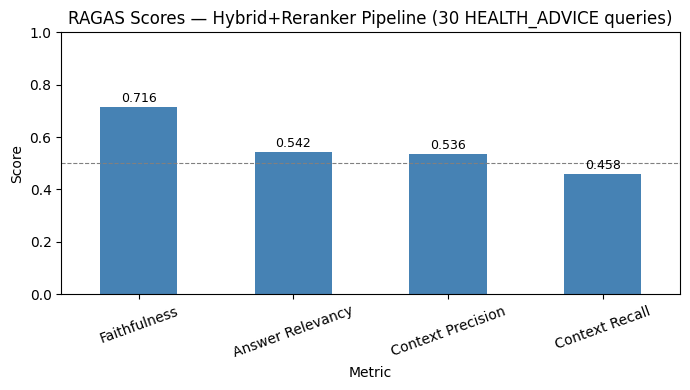

Saved: reports/en/ragas_scores.png


In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
df['Score'].plot(
    kind='bar', ax=ax,
    title='RAGAS Scores — Hybrid+Reranker Pipeline (30 HEALTH_ADVICE queries)',
    ylim=(0, 1), rot=20, color='steelblue'
)
ax.set_ylabel('Score')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)

for i, v in enumerate(df['Score']):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('reports/en/ragas_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/en/ragas_scores.png')